In [43]:
import sys
sys.path.insert(0, "/mnt/c/Users/marrs/Desktop/UCL_dissertation/ucl-fgd")

from utils.text_utils import *
import pandas as pd

In [44]:
def group_sentences(df):
    """
    Groups sentences by sentence_group, levels_of_embedding, and condition.
    
    Returns:
        dict of {sentence_group: {levels_of_embedding: {condition: row as dict}}}
    """
    result = {}
    
    for _, row in df.iterrows():
        group = row["sentence_group"]
        level = row["levels_of_embedding"]
        condition = row["condition"]
        
        if group not in result:
            result[group] = {}
        
        if level not in result[group]:
            result[group][level] = {}
        
        result[group][level][condition] = row.to_dict()
    
    return result

In [45]:
df = pd.read_csv("../data/model_outputs/gpt2_pilot_object_gaps_output_stimuli_with_surprisals.csv")
grouped = group_sentences(df)

# access sentence group 1, embedding level 2
row = grouped[3][0]["no_gap_no_filler"]
print(row)
#for row in rows:
#    print(row["condition"], row["complementiser_surprisal"])

{'sentence_group': 3, 'gap': 'no', 'filler': 'no', 'levels_of_embedding': 0, 'condition': 'no_gap_no_filler', 'main_clause': 'I know', 'complementiser': 'that', 'embedding_1': nan, 'embedding_2': nan, 'embedding_3': nan, 'subject': 'the burglar', 'verb': 'stole', 'object': nan, 'continuation': 'the other night.', 'complementiser_surprisal': 2.74974, 'object_surprisal': nan, 'subject_surprisal': 4.424285, 'continuation_surprisal': 3.408626}


**Wilcox 2022, wh-effect**

| | +gap | -gap |
|---|---|---|
| **-filler** | I know what the lion devoured _ at sunrise. | *I know that the lion devoured _ at sunrise. |
| **+filler** | *I know what the lion devoured a gazelle at sunrise. | I know that the lion devoured a gazelle at sunrise. |

---

**filler_offloading**
| | -filler | +filler |
|---|---|---|
| **+gap** | I know what the lion devoured _ at sunrise. | *I know what the lion devoured a gazelle at sunrise. |
| **-gap** | *I know that the lion devoured _ at sunrise. | I know that the lion devoured a gazelle at sunrise. |


In [ ]:
def compute_metrics(grouped):
    metrics = {}
    
    for group_id, levels in grouped.items():
        metrics[group_id] = {}
        
        for level, rows in levels.items():
            metrics[group_id][level] = {
              "wh_effect_no_filler": rows["gap_no_filler"]["continuation_surprisal"] - rows["no_gap_no_filler"]["continuation_surprisal"],
              "wh_effect_filler": rows["gap_filler"]["object_surprisal"] - rows["no_gap_filler"]["object_surprisal"],
              "filler_offloading_gap": rows["gap_no_filler"]["continuation_surprisal"] - rows["gap_filler"]["continuation_surprisal"],
              "filler_offloading_no_gap": rows["no_gap_no_filler"]["continuation_surprisal"] - rows["no_gap_filler"]["continuation_surprisal"]
              
            }
    
    return metrics

In [ ]:
metrics = compute_metrics(grouped)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics(metrics):
    for group_id, levels in metrics.items():
        n_levels = len(levels)
        fig, axes = plt.subplots(1, n_levels, figsize=(5 * n_levels, 5), sharey=True)
        
        if n_levels == 1:
            axes = [axes]
        
        fig.suptitle(f"Sentence Group {group_id}", fontsize=14)
        
        for ax, (level, level_metrics) in zip(axes, sorted(levels.items())):
            labels = list(level_metrics.keys())
            values = list(level_metrics.values())
            colors = ["green" if "wh_effect" in l else "purple" for l in labels]
            short_labels = [l.replace("wh_effect_", "").replace("filler_offloading_", "") for l in labels]
            
            x = np.arange(len(labels))
            bars = ax.bar(x, values, color=colors)
            ax.set_title(f"Embedding level {level}")
            ax.set_xticks(x)
            ax.set_xticklabels(short_labels, rotation=30, ha="right", fontsize=8)
            ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        
        plt.tight_layout()
        plt.show()

# Metrics
in all cases if model predicts gramaticality we would expect the left bar to be negative and the right to be positive.

##  gpt2 metrics

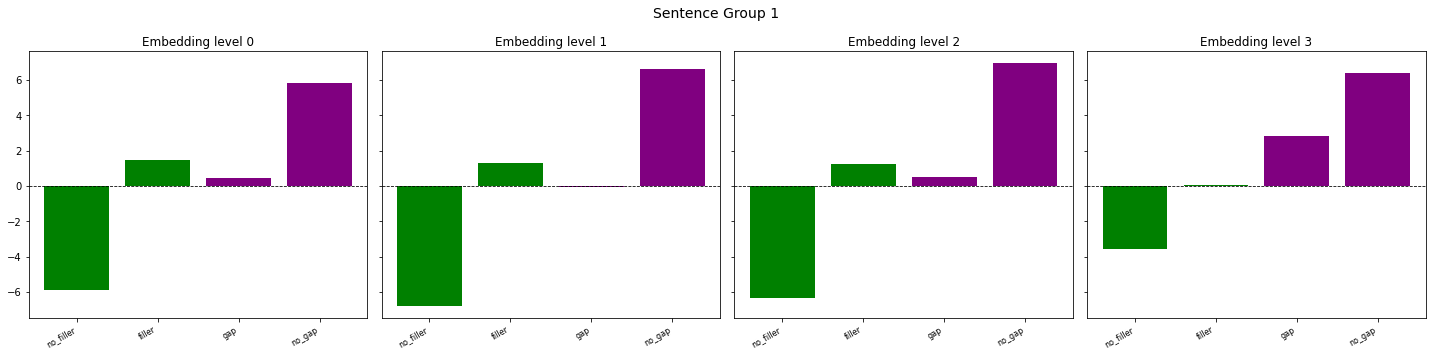

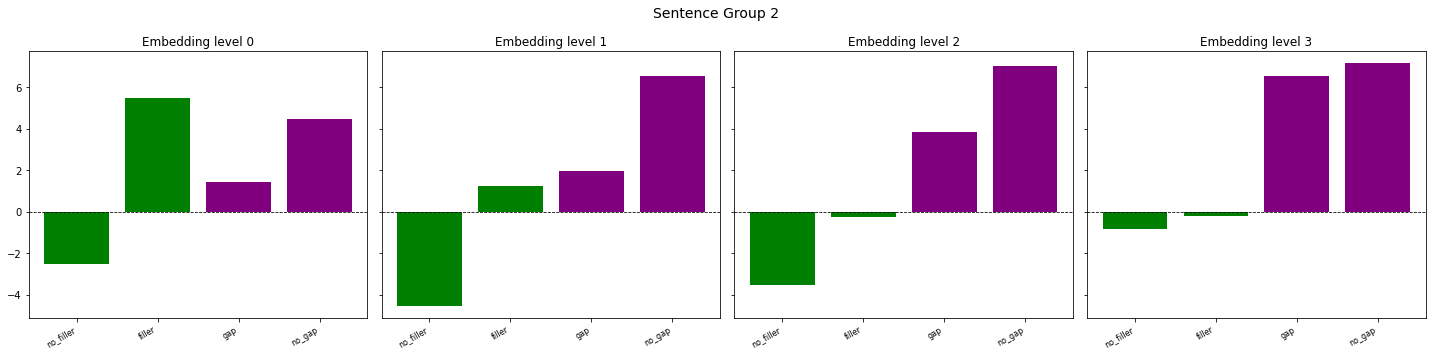

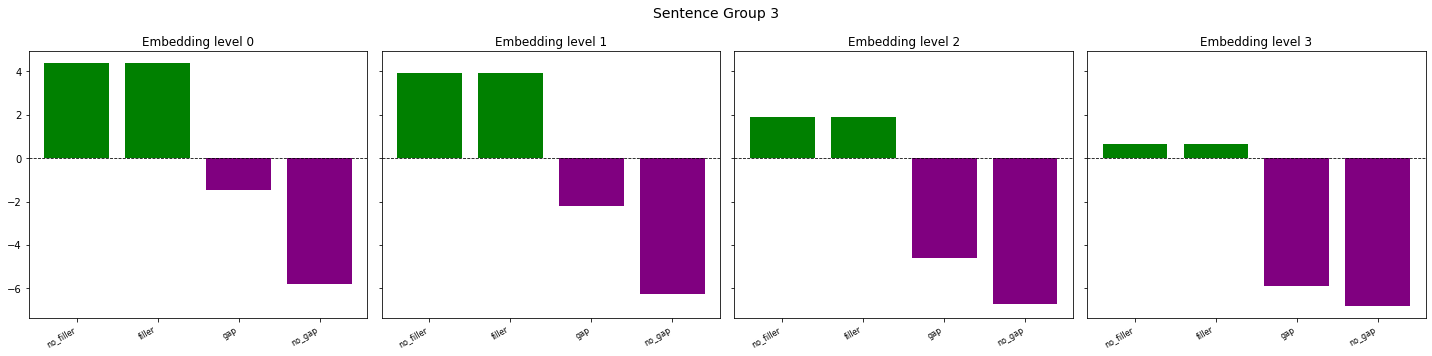

In [47]:
df = pd.read_csv("../data/model_outputs/gpt2_pilot_object_gaps_output_stimuli_with_surprisals.csv")
grouped = group_sentences(df)
metrics = compute_metrics(grouped)
plot_metrics(metrics)

## ngram metrics
the only reason these are different is that in my case the preceding 5 words maybe different (comparing between filled gap and not-filled gap conditions), this isn't especially relevant

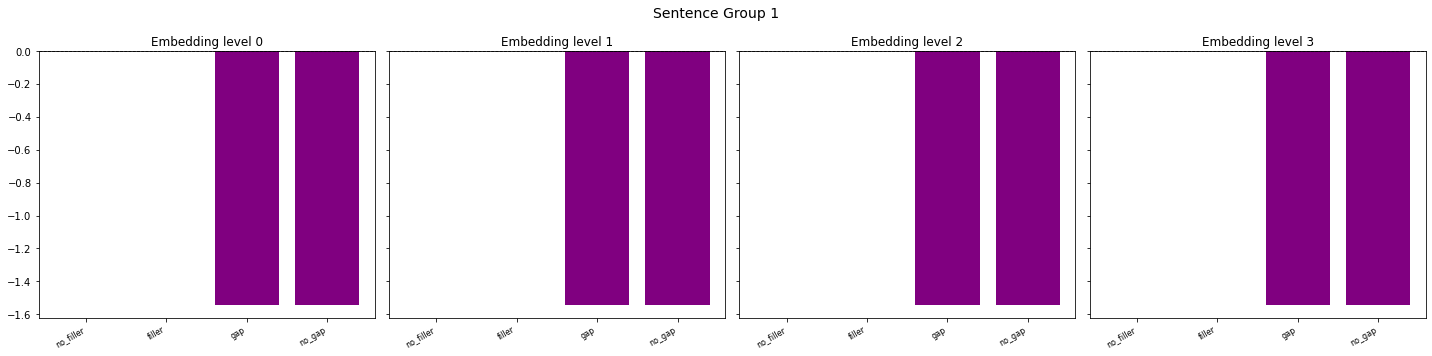

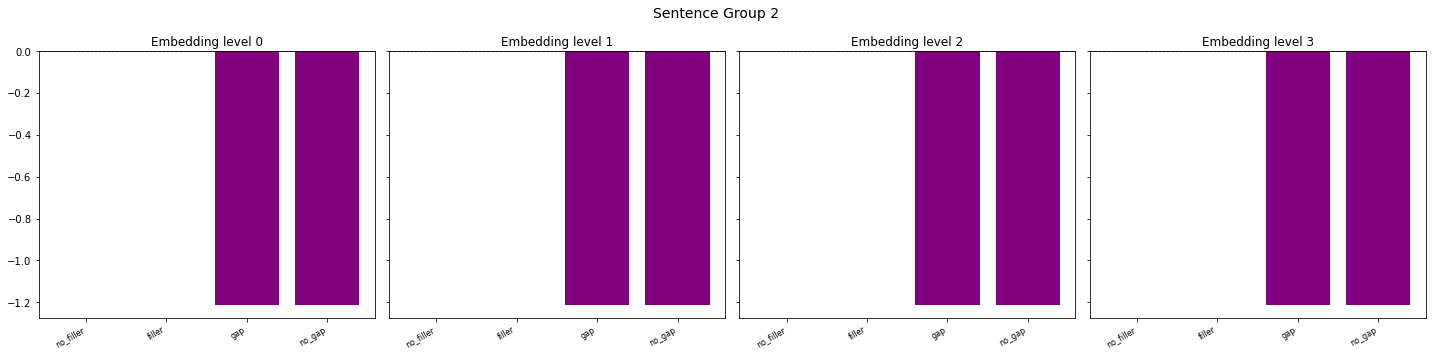

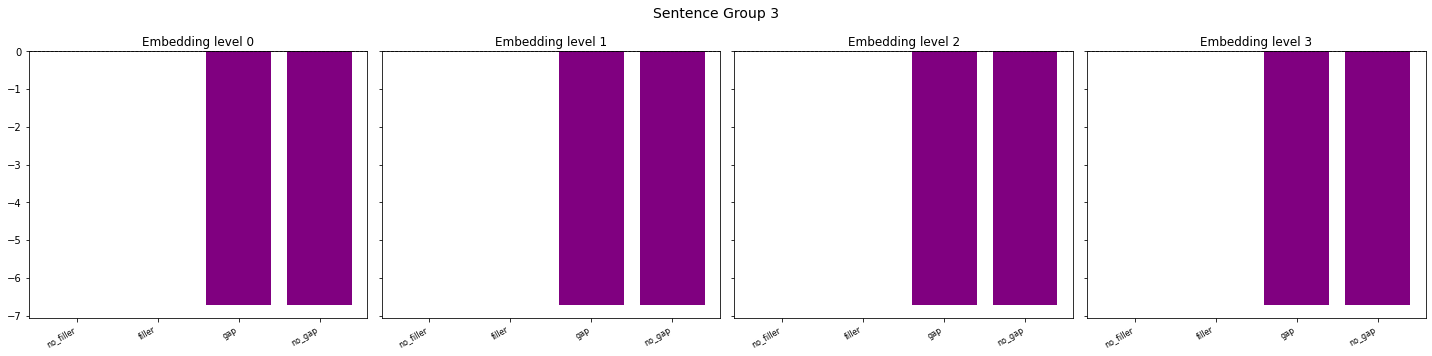

In [ ]:
df = pd.read_csv("../data/model_outputs/ngram_pilot_object_gaps_output_stimuli_with_surprisals.csv")
grouped = group_sentences(df)
metrics = compute_metrics(grouped)
plot_metrics(metrics)

## grnn metrics

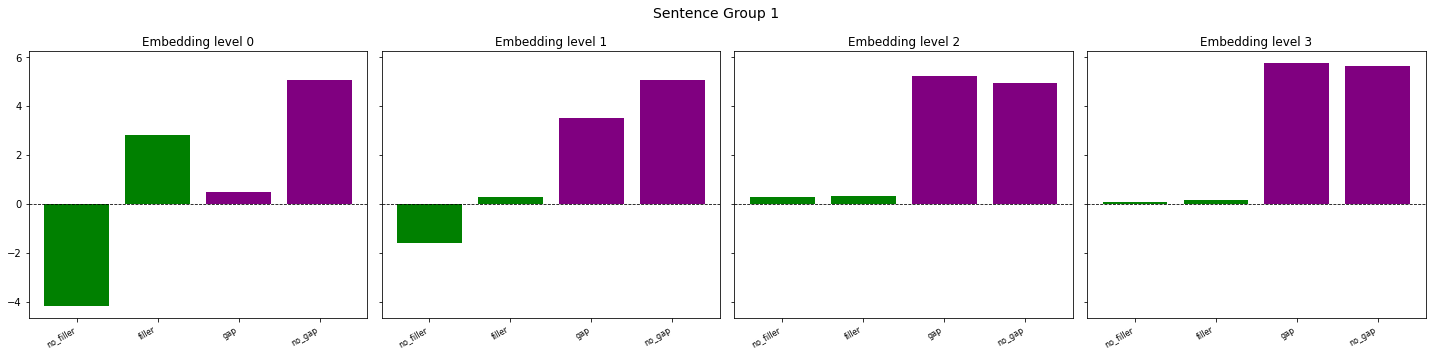

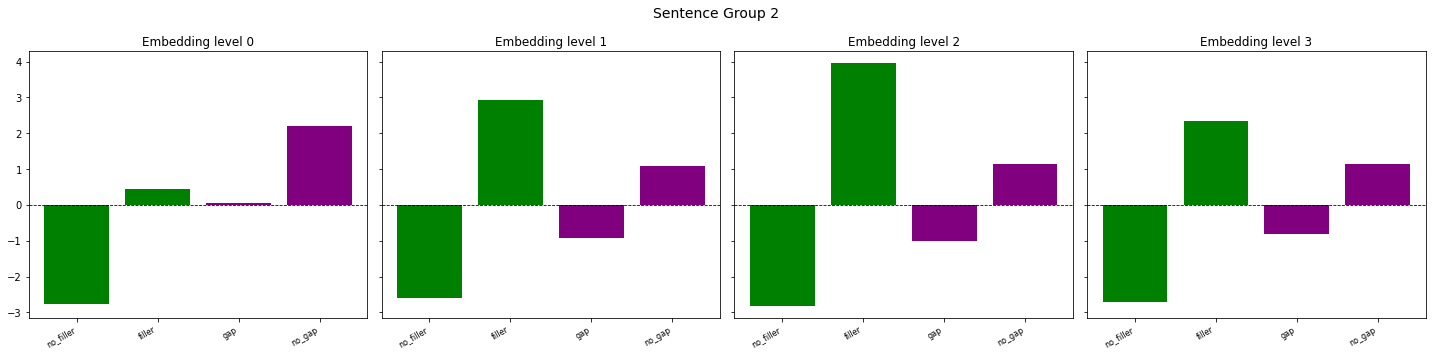

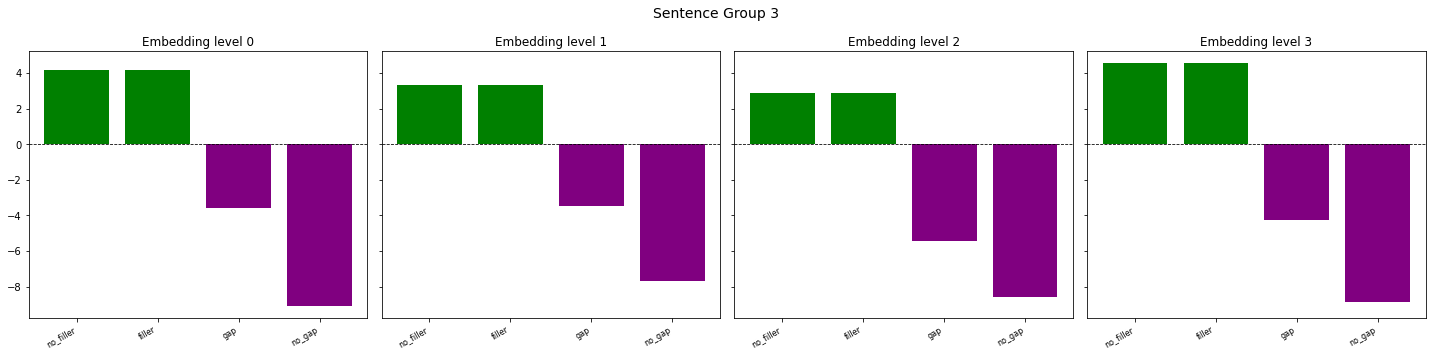

In [42]:
df = pd.read_csv("../data/model_outputs/grnn_pilot_object_gaps_output_stimuli_with_surprisals.csv")
grouped = group_sentences(df)
metrics = compute_metrics(grouped)
plot_metrics(metrics)